# First Logistic Regression Model for TON-IoT

Dataset: `train_test_network.csv`

Target:

- `label = 0`: normal traffic
- `label = 1`: attack traffic

## 1. Import Libraries

Start by importing the libraries you will use.

Try typing these yourself first. If you get stuck, copy the snippet.

In [1]:

import pandas as pd
import numpy as np


In [3]:

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

## 2. Load the Dataset

Use `pd.read_csv()` to load the CSV file into a DataFrame named `df`.

In [5]:
DATA_PATH = "train_test_network.csv"
df = pd.read_csv(DATA_PATH)

In [ ]:
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


## 3. Choose Features for the First Model

Only using numeric columns to keep the model simple. 

Next, we should include categorical columns like `proto`, `service`, and `conn_state`.

In [58]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'label']


In [57]:
numeric_features = [col for col in numeric_cols if col != "label"]
print(len(numeric_features))

16


In [37]:
# TODO: Create X from the numeric feature columns
# TODO: Create y from the label column

X = df[numeric_features] #input features
y = df["label"] #target variable

## 4. Train/Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [56]:

X_train.shape, X_test.shape

((158282, 16), (52761, 16))

## 4. Scale the Numeric Features

We are scaling the features because some columns have big disparities in their numerical values. This helps logistic regression learn better

In [42]:
scaler = StandardScaler()

In [44]:
X_train_scaled = scaler.fit_transform(X_train)


In [45]:
X_test_scaled = scaler.transform(X_test)

## 5. Train the Logistic Regression Model

In [59]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state = 42
)

In [47]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

- using`class_weight="balanced"` to address imbalanced classes in the dataset

## 6. Make Predictions

In [49]:
y_pred = model.predict(X_test_scaled)

## 7. Evaluate the Model

In [50]:
# TODO: Calculate accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1", f1)


Accuracy: 0.8519171357631584
Precision: 0.8852034759485256
Recall: 0.9260326370432925
F1 0.9051578679032277


In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.61      0.66     12500
           1       0.89      0.93      0.91     40261

    accuracy                           0.85     52761
   macro avg       0.80      0.77      0.78     52761
weighted avg       0.85      0.85      0.85     52761



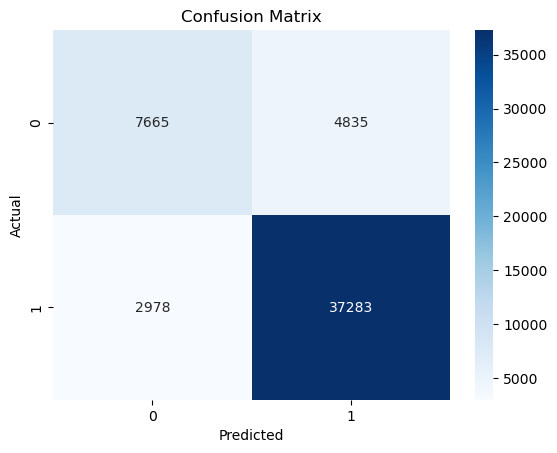

In [52]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


- precision -> important when the cost of a false positive is high
- recall -> important when the cost of a false negative is high

## 8. Inspect Model Coefficients

In [53]:
coef_df = pd.DataFrame({
    "feature": numeric_features,
    "coefficient": model.coef_[0]
})

In [54]:
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_df

,feature,coefficient,abs_coefficient
11,dns_qtype,-14.679752,14.679752
7,src_ip_bytes,8.074182,8.074182
6,src_pkts,-4.618274,4.618274
14,http_response_body_len,-0.935626,0.935626
1,dst_port,-0.546122,0.546122
10,dns_qclass,-0.318214,0.318214
12,dns_rcode,-0.223178,0.223178
4,dst_bytes,0.208960,0.208960
3,src_bytes,0.203860,0.203860
2,duration,-0.176902,0.176902
